# Modèle étendu (5,35 ans) — journée du 31/07/2026

**Origine** : 23 h heure de Paris la veille, dérivée de `ORIGIN_HOUR_PARIS`
(`dags/forecast_daily_dag.py`) et non codée en dur — en hiver la même origine
vaut 22 h UTC et non 21 h.

| série | provenance |
|---|---|
| champion | **prévision stockée**, telle qu'émise en production à 00h12 |
| RTE (J-1) | **prévision stockée**, API RTE |
| **modèle étendu** | **recalculé** à la même origine — il ne tournait pas en production |
| réalisé | observations RTE |

Le modèle étendu est reconstruit avec la prévision de température archivée à
**échéance J-1** : ce dont on disposait la veille, jamais l'observé du 31/07.
En production il aurait eu une prévision plus fraîche, donc cette
reconstruction le désavantage plutôt qu'elle ne le flatte.

---

## Avertissement : 2 heures de réalisé

À l'heure de rédaction, RTE n'a publié que **2 heures** de consommation pour le
31/07. **Deux points ne classent pas trois modèles** — l'écart qu'on y lira est
du bruit pur. Ce notebook sert à voir les trois trajectoires sur la journée
entière et à contrôler qu'elles sont plausibles ; il se remplira de lui-même en
le rejouant plus tard.

Ce qui départage vraiment, c'est le backtest sur 190 origines rappelé en
conclusion.

In [1]:
import os, sys, warnings
from datetime import date, datetime, time, timedelta
from zoneinfo import ZoneInfo

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

_ROOT = os.getcwd()
while not os.path.isdir(os.path.join(_ROOT, "pipeline_prevision")):
    _ROOT = os.path.dirname(_ROOT)
sys.path.insert(0, _ROOT); os.chdir(_ROOT)
warnings.filterwarnings("ignore")

from pipeline_prevision.db import get_observations
from pipeline_prevision.db.config import get_engine
from pipeline_prevision.utils.main_utils.utils import load_object
from pipeline_prevision.utils.main_utils.feature_engineering import (
    HORIZON_MAX, build_origin_feature_frame, build_series_by_target,
    select_temperature, select_forecast_temperature)
from pipeline_prevision.utils.ml_utils.model.local_forecaster import (
    _direct_prediction, get_anchor)
from pipeline_prevision.utils.main_utils.prevision_temperature_france import (
    archive_prevision_france)

PARIS, TZ = ZoneInfo("Europe/Paris"), os.getenv("DISPLAY_TZ", "Europe/Paris")
ORIGIN_HOUR_PARIS = 23              # = dags/forecast_daily_dag.py
JOUR_PREVU, CIBLE = date(2026, 7, 31), "consommation_totale"
MODELE_ETENDU = os.path.join(
    r"C:\Users\saida\AppData\Local\Temp\claude"
    r"\d--Nouveau-dossier-TitreRNCP-Bloc1-projet-prevision-energies-bloc5"
    r"\0eab1609-b083-46cc-a41d-5eba4738161d\scratchpad", "etendu_models")

ORIGINE = pd.Timestamp(datetime.combine(JOUR_PREVU - timedelta(days=1),
                                        time(ORIGIN_HOUR_PARIS), tzinfo=PARIS)
                       .astimezone(ZoneInfo("UTC")).replace(tzinfo=None))
CIBLES = pd.date_range(ORIGINE + pd.Timedelta(hours=1), periods=HORIZON_MAX, freq="h")

def en_local(ix):
    """UTC naïf -> heure locale, même convention que streamlit_app/data.py."""
    ix = pd.DatetimeIndex(pd.to_datetime(ix))
    return (ix.tz_localize("UTC") if ix.tz is None else ix).tz_convert(TZ).tz_localize(None)

INK, INK_2, MUTED, GRID, AXIS, SURF = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7", "#fcfcfb"
C_CHAMP, C_NEUF, C_RTE, POS, NEG = "#2a78d6", "#eb6834", "#1baf7a", "#2a78d6", "#e34948"
plt.rcParams.update({"figure.facecolor": SURF, "axes.facecolor": SURF,
    "font.family": "sans-serif", "font.size": 10, "axes.edgecolor": AXIS,
    "axes.labelcolor": INK_2, "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": .8,
    "axes.spines.top": False, "axes.spines.right": False})
print(f"Origine {ORIGINE} UTC = {en_local([ORIGINE])[0]:%d/%m %Hh} locale")

Origine 2026-07-30 21:00:00 UTC = 30/07 23h locale


In [2]:
def stocke(variable, origin=None):
    sql = ("SELECT target_ts, y_pred, model_version FROM forecasts WHERE variable=%(v)s "
           "AND target_ts > %(a)s AND target_ts <= %(b)s")
    par = {"v": variable, "a": ORIGINE, "b": CIBLES[-1]}
    if origin is not None:
        sql += " AND origin_ts = %(o)s"; par["o"] = origin
    return pd.read_sql(sql + " ORDER BY target_ts", get_engine(), params=par,
                       parse_dates=["target_ts"]).set_index("target_ts")

champion = stocke(CIBLE, origin=ORIGINE)
rte = stocke("consommation_totale_rte")
obs = get_observations().sort_index()
reel = pd.to_numeric(obs[CIBLE], errors="coerce").reindex(CIBLES)

assert not champion.empty, f"aucune prévision champion stockée à l'origine {ORIGINE}"
print(f"champion : {len(champion)} pts · {champion['model_version'].iloc[0]} (stockée)")
print(f"RTE      : {len(rte)} pts (stockée)")
print(f"réalisé  : {int(reel.notna().sum())}/{HORIZON_MAX} heures publiées")

champion : 24 pts · sha256:6568b5d26de8 (stockée)
RTE      : 24 pts (stockée)
réalisé  : 20/24 heures publiées


In [3]:
# Le seul calcul : observations tranchées à l'origine, aucune donnée postérieure
# n'entre dans les features. Température prévue = archive J-1.
obs_o = obs.loc[:ORIGINE]
temp_prev = archive_prevision_france(
    (ORIGINE - pd.Timedelta(days=3)).to_pydatetime(),
    (ORIGINE + pd.Timedelta(hours=HORIZON_MAX + 1)).to_pydatetime(), lead_jours=1)

_c = load_object(os.path.join(MODELE_ETENDU, "model.pkl"))
entry = _c[CIBLE]; del _c
cols, prefix = entry["feature_columns"], entry["prefix"]
cadre, _ = build_origin_feature_frame(
    build_series_by_target(obs_o), select_temperature(obs_o), CIBLE, temp_prev=temp_prev)
ligne = cadre.loc[[ORIGINE]]
assert not [c for c in cols if ligne[c].isna().any()], "features NaN à l'origine"

etendu = pd.Series([float(_direct_prediction(
    entry["models"][h], entry["alphas"][h], entry["seasonal_weights"][h],
    ligne[cols], h, prefix, f"{prefix}_delta_1", get_anchor(entry, h))[0])
    for h in range(1, HORIZON_MAX + 1)], index=CIBLES)

pred = pd.DataFrame({"réalisé": reel, "champion": champion["y_pred"].reindex(CIBLES),
                     "étendu (5,35 ans)": etendu, "RTE (J-1)": rte["y_pred"].reindex(CIBLES)})
print(f"Observations vues : jusqu'à {obs_o.index.max()}")
(pred / 1000).round(2)

Observations vues : jusqu'à 2026-07-30 21:00:00


,réalisé,champion,"étendu (5,35 ans)",RTE (J-1)
2026-07-30 22:00:00,44.25,44.31,43.86,43.97
2026-07-30 23:00:00,42.11,41.15,40.95,41.90
2026-07-31 00:00:00,39.86,39.70,39.51,39.84
2026-07-31 01:00:00,37.89,37.69,37.50,37.55
2026-07-31 02:00:00,37.33,36.94,36.82,36.79
2026-07-31 03:00:00,38.41,37.25,37.50,37.33
2026-07-31 04:00:00,40.37,39.29,39.80,39.15
2026-07-31 05:00:00,42.09,42.10,41.97,41.69
2026-07-31 06:00:00,45.11,45.64,45.28,44.54
2026-07-31 07:00:00,46.93,48.11,47.13,46.45


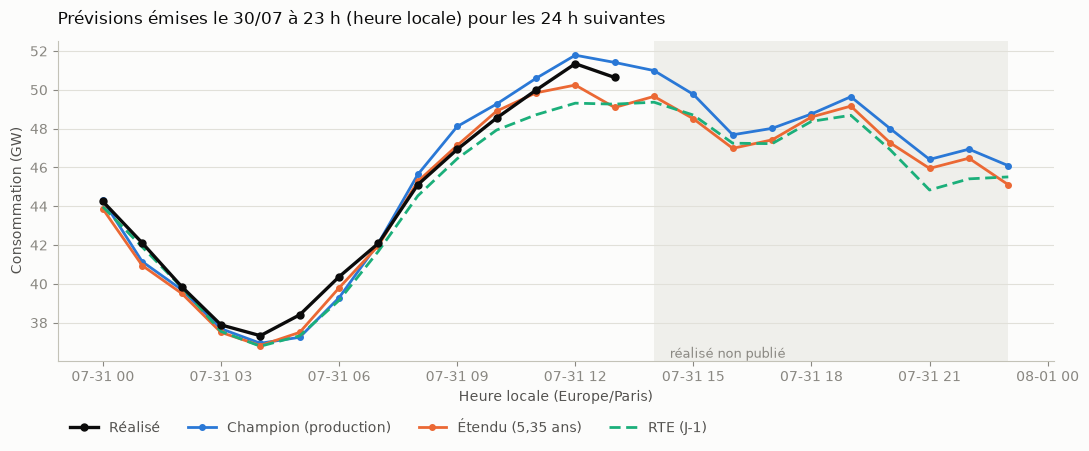

In [17]:
fig, ax = plt.subplots(figsize=(11, 4.6))
x = en_local(pred.index)
ax.plot(x, pred["réalisé"] / 1000, color=INK, lw=2.4, marker="o", ms=5, zorder=5, label="Réalisé")
ax.plot(x, pred["champion"] / 1000, color=C_CHAMP, lw=2, marker="o", ms=4, label="Champion (production)")
ax.plot(x, pred["étendu (5,35 ans)"] / 1000, color=C_NEUF, lw=2, marker="o", ms=4, label="Étendu (5,35 ans)")
ax.plot(x, pred["RTE (J-1)"] / 1000, color=C_RTE, lw=2, ls=(0, (4, 2)), label="RTE (J-1)")
trous = x[pred["réalisé"].isna().to_numpy()]
if len(trous):
    ax.axvspan(trous[0], x[-1], color=GRID, alpha=.45, lw=0, zorder=0)
    ax.text(trous[0] + pd.Timedelta(hours=.3), ax.get_ylim()[0], " réalisé non publié",
            color=MUTED, fontsize=9, va="bottom")
ax.set_ylabel("Consommation (GW)", color=INK_2)
ax.set_xlabel(f"Heure locale ({TZ})", color=INK_2)
ax.set_title("Prévisions émises le 30/07 à 23 h (heure locale) pour les 24 h suivantes",
             color=INK, fontsize=12, loc="left", pad=12)
ax.legend(frameon=False, ncol=4, loc="upper left", labelcolor=INK_2, bbox_to_anchor=(0, -.14))
ax.grid(axis="x", visible=False); fig.autofmt_xdate(rotation=0, ha="center")
plt.tight_layout(); plt.show()

In [18]:
MODELES = ["champion", "étendu (5,35 ans)", "RTE (J-1)"]
ev = pred.dropna(subset=["réalisé"]).copy()
tab = pd.DataFrame({"horizon_h": range(1, len(ev) + 1),
                    "heure_locale": en_local(ev.index).strftime("%d/%m %Hh"),
                    "heure_UTC": ev.index.strftime("%d/%m %Hh"),
                    "réalisé_GW": (ev["réalisé"] / 1000).values})
for m in MODELES:
    tab[f"err_{m}_MW"] = (ev[m] - ev["réalisé"]).abs().values
tab["gain_vs_champion_%"] = 100 * (tab["err_champion_MW"]
                                   - tab["err_étendu (5,35 ans)_MW"]) / tab["err_champion_MW"]
tab.set_index("horizon_h").round(1)

,heure_locale,heure_UTC,réalisé_GW,err_champion_MW,"err_étendu (5,35 ans)_MW",err_RTE (J-1)_MW,gain_vs_champion_%
horizon_h,,,,,,,
1,31/07 00h,30/07 22h,44.2,63.5,389.3,274.2,-512.9
2,31/07 01h,30/07 23h,42.1,962.8,1162.8,209.0,-20.8
3,31/07 02h,31/07 00h,39.9,158.9,348.9,25.2,-119.6
4,31/07 03h,31/07 01h,37.9,196.7,386.5,337.2,-96.5
5,31/07 04h,31/07 02h,37.3,388.5,507.7,543.0,-30.7
6,31/07 05h,31/07 03h,38.4,1157.3,902.5,1080.8,22.0
7,31/07 06h,31/07 04h,40.4,1078.2,571.5,1217.0,47.0
8,31/07 07h,31/07 05h,42.1,4.5,121.6,406.2,-2617.8
9,31/07 08h,31/07 06h,45.1,524.6,169.3,575.2,67.7


In [19]:
res = pd.DataFrame({
    "MAE (MW)": [tab[f"err_{m}_MW"].mean() for m in MODELES],
    "biais moyen (MW)": [(ev[m] - ev["réalisé"]).mean() for m in MODELES],
}, index=MODELES)
res["gain vs champion (%)"] = 100 * (res.loc["champion", "MAE (MW)"] - res["MAE (MW)"]) / res.loc["champion", "MAE (MW)"]
res["gain vs RTE (%)"] = 100 * (res.loc["RTE (J-1)", "MAE (MW)"] - res["MAE (MW)"]) / res.loc["RTE (J-1)", "MAE (MW)"]
print(f"Sur {len(tab)} horizon(s) évalué(s) — trop peu pour classer quoi que ce soit\n")
res.round(1)

Sur 14 horizon(s) évalué(s) — trop peu pour classer quoi que ce soit



,MAE (MW),biais moyen (MW),gain vs champion (%),gain vs RTE (%)
champion,590.0,26.8,0.0,20.9
"étendu (5,35 ans)",564.6,-460.2,4.3,24.3
RTE (J-1),745.9,-745.9,-26.4,0.0


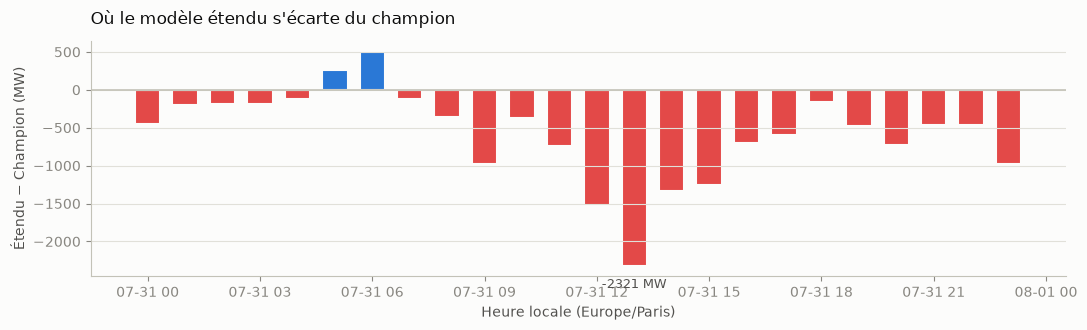

In [20]:
# Écart entre les deux modèles sur les 24 h, réalisé ou non : ce que le nouveau
# modèle change dans la prévision, indépendamment de ce qu'on peut encore scorer.
fig, ax = plt.subplots(figsize=(11, 3.4))
ecart = (pred["étendu (5,35 ans)"] - pred["champion"]).to_numpy()
xl = en_local(pred.index)
ax.bar(xl, ecart, color=[POS if v >= 0 else NEG for v in ecart],
       width=pd.Timedelta(hours=.68), edgecolor=SURF, linewidth=1.5)
ax.axhline(0, color=AXIS, lw=1.2)
ax.set_ylabel("Étendu − Champion (MW)", color=INK_2)
ax.set_xlabel(f"Heure locale ({TZ})", color=INK_2)
ax.set_title("Où le modèle étendu s'écarte du champion", color=INK, fontsize=12, loc="left", pad=12)
i = int(np.argmax(np.abs(ecart)))
ax.annotate(f"{ecart[i]:+.0f} MW", (xl[i], ecart[i]), textcoords="offset points",
            xytext=(0, 8 if ecart[i] >= 0 else -16), ha="center", color=INK_2, fontsize=9)
ax.grid(axis="x", visible=False); fig.autofmt_xdate(rotation=0, ha="center")
plt.tight_layout(); plt.show()

## Conclusion

**Les chiffres ci-dessus ne départagent rien.** Sur si peu d'heures publiées,
l'intervalle de confiance d'un écart de MAE couvre largement zéro. Le graphe
des écarts sert d'inspection : il montre *où* le nouveau modèle change d'avis,
pas s'il a raison.

### Ce qui départage réellement

Backtest à origine glissante, 190 origines de production, fenêtre
hors-échantillon commune (2026-01-18 → 2026-07-26) :

| catégorie | n | 3,58 ans | 5,35 ans | gain | RTE | vs RTE |
|---|---|---|---|---|---|---|
| mardi–vendredi | 2 328 | 736 | 724 | +1,6 % | 780 | **+7,2 %** |
| **lundi** | 576 | 850 | **772** | **+9,2 %** | 801 | **+3,6 %** |
| samedi | 600 | 942 | 853 | +9,4 % | 817 | −4,3 % |
| dimanche | 580 | 733 | 698 | +4,8 % | 812 | **+14,0 %** |
| férié | 144 | 985 | **1 438** | **−45,9 %** | 865 | −66,2 % |
| **toutes** | 4 516 | 814 | **793** | **+2,5 %** | **796** | **+0,3 %** |

Le modèle étendu **passe devant RTE pour la première fois** (793 contre 796),
et corrige le lundi de 9,2 % — la catégorie visée depuis le diagnostic. Mais
l'IC95 de l'écart avec RTE est [−87,2 ; +52,9] MW : **statistiquement, c'est
une égalité**, et les fériés se dégradent de 45,9 % sur 6 jours seulement.

Trois expériences successives se terminent par « direction favorable, IC95 qui
croise zéro ». La fenêtre d'évaluation est le facteur limitant, pas les idées :
une validation à origine glissante sur tout l'historique évaluerait sur
**49 fériés et 233 lundis** au lieu de 6 et 24.